# AML23703 – Quantum Computing

## Tutorial 4: Multi-Qubit Gates and Circuit Composition

---

**Name:** Mythri M R

**USN:** 1GA23AI027

**Department:** Artificial Intelligence and Machine Learning

**Semester:** VII

**Course Code:** AML23703

**Date:** 121-08-2026

## Aim

To implement and analyze multi-qubit quantum gates such as CNOT, CZ and Toffoli gates using Qiskit, construct entangled quantum states, and verify their behavior using quantum state visualization and measurement results.

## Theory

Multi-qubit gates operate on two or more qubits.

CNOT uses one qubit as a control and another as a target.  
CZ applies a controlled phase change.  
Toffoli uses two control qubits to control one target.

These gates are used to create entanglement and build larger quantum circuits.

## Gate Summary

| Gate | Purpose |
|------|---------|
| CNOT | Flips target when control is 1 |
| CZ | Applies a controlled phase change |
| Toffoli | Flips target when both controls are 1 |

## Required Libraries

In [24]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_state_qsphere,
    plot_state_city,
    plot_histogram
)
from qiskit_aer import AerSimulator
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# Exercise 1 – Easy

## CNOT Gate

### Objective

Implement a CNOT gate with the control qubit in |1⟩ and verify that the target qubit flips.

### Theory

CNOT has one control and one target qubit.

If the control is 1, the target flips.

For example:

| Before | After |
|--------|-------|
| 10 | 11 |


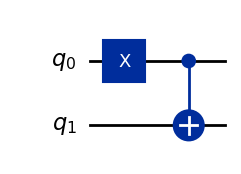

State Vector: [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
Probabilities: [0. 0. 0. 1.]


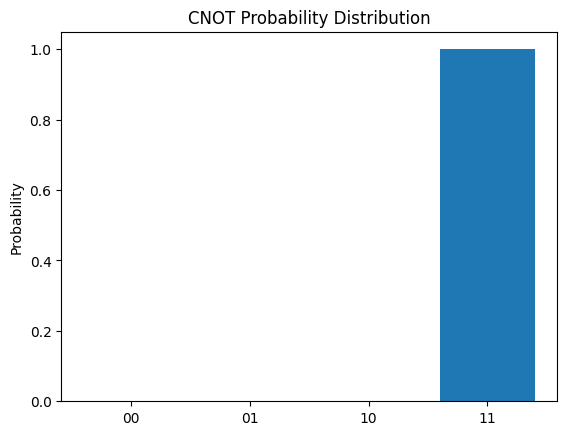

In [25]:
qc1 = QuantumCircuit(2)
qc1.x(0)
qc1.cx(0, 1)

display(qc1.draw("mpl"))

state1 = Statevector.from_instruction(qc1)

print("State Vector:", np.round(state1.data, 3))
print("Probabilities:", np.round(np.abs(state1.data)**2, 2))

plt.bar(["00", "01", "10", "11"], np.abs(state1.data)**2)
plt.title("CNOT Probability Distribution")
plt.ylabel("Probability")
plt.show()

### Observation

The control qubit was set to |1⟩, so the CNOT gate flipped the target qubit from |0⟩ to |1⟩. The final state was |11⟩ with probability 1.

# Exercise 2 – Medium: Bell State

Build a Bell state circuit and run 1024 shots to verify that the measurement outcomes are mainly 00 and 11.

A Bell state is created by applying a Hadamard gate followed by a CNOT gate. It produces entanglement between the two qubits.

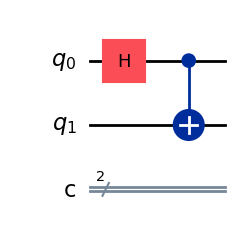

State Vector: [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]
Probabilities: [0.5 0.  0.  0.5]
1024 Shot Results: {'00': 505, '11': 519}


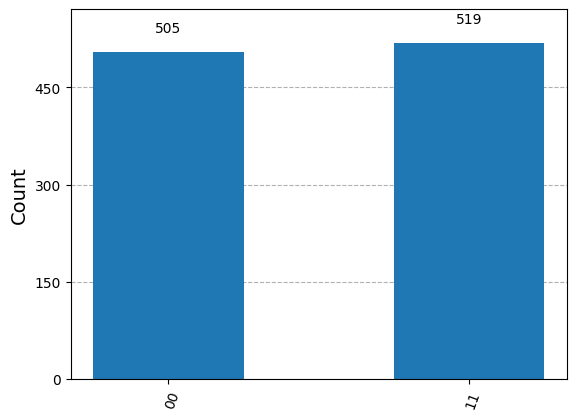

In [26]:
qc2 = QuantumCircuit(2, 2)
qc2.h(0)
qc2.cx(0, 1)

state2 = Statevector.from_instruction(qc2)

display(qc2.draw("mpl"))

print("State Vector:", np.round(state2.data, 3))
print("Probabilities:", np.round(np.abs(state2.data)**2, 2))

qc2.measure([0, 1], [0, 1])
counts2 = simulator.run(qc2, shots=1024).result().get_counts()

print("1024 Shot Results:", counts2)

display(plot_histogram(counts2))

### Observation

The Bell state produced the measurement outcomes 00 and 11 with approximately equal probabilities. This shows that the two qubits are entangled.

# Exercise 3 – Hard: 3-Qubit GHZ State

Implement a 3-qubit GHZ state and confirm perfect three-way correlation in the measurement results.

A GHZ state is created using a Hadamard gate and two CNOT gates. The expected measurement outcomes are 000 and 111.

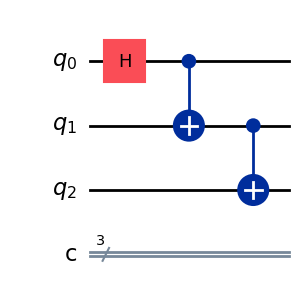

State Vector: [0.707+0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j
 0.707+0.j]
Probabilities: [0.5 0.  0.  0.  0.  0.  0.  0.5]
1024 Shot Results: {'111': 506, '000': 518}


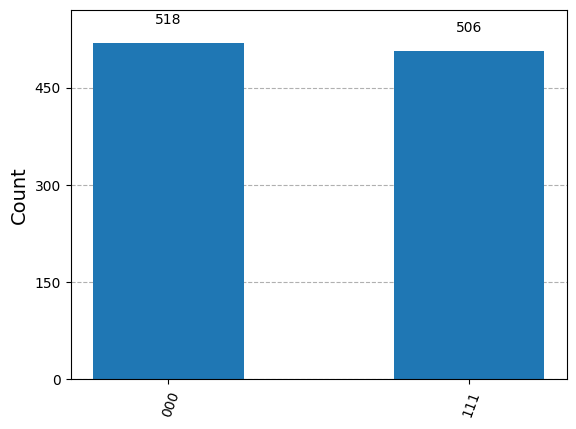

In [27]:
qc3 = QuantumCircuit(3, 3)
qc3.h(0)
qc3.cx(0, 1)
qc3.cx(1, 2)

state3 = Statevector.from_instruction(qc3)

display(qc3.draw("mpl"))

print("State Vector:", np.round(state3.data, 3))
print("Probabilities:", np.round(np.abs(state3.data)**2, 2))

qc3.measure([0, 1, 2], [0, 1, 2])
counts3 = simulator.run(qc3, shots=1024).result().get_counts()

print("1024 Shot Results:", counts3)

display(plot_histogram(counts3))

### Observation

The GHZ state produced mainly the measurement outcomes 000 and 111. This shows that all three qubits are correlated.

# Exercise 4 – Real World: Quantum Full Adder

Implement a classical full-adder circuit using CNOT and Toffoli gates.

A full adder adds three binary inputs: A, B and Carry-in, and produces Sum and Carry-out. CNOT is used for XOR operations and Toffoli is used for carry calculation.

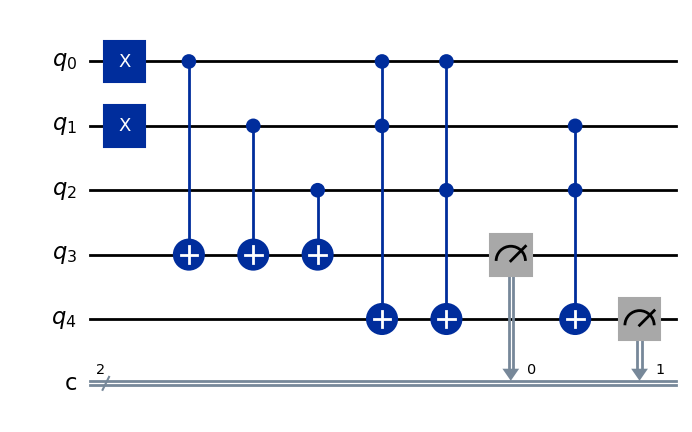

Input: A=1, B=1, Carry-in=0
Result: {'10': 1024}


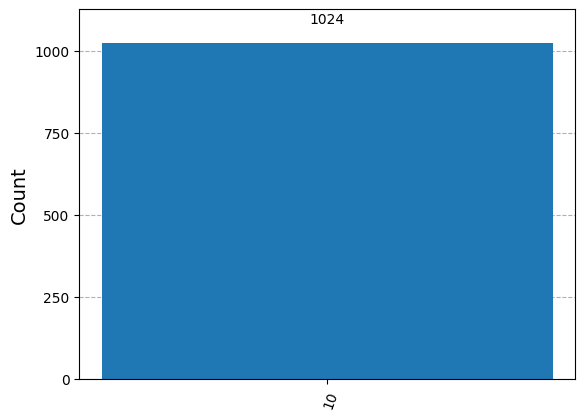

In [28]:
def full_adder(a, b, cin):
    qc = QuantumCircuit(5, 2)

    if a: qc.x(0)
    if b: qc.x(1)
    if cin: qc.x(2)

    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)

    qc.ccx(0, 1, 4)
    qc.ccx(0, 2, 4)
    qc.ccx(1, 2, 4)

    qc.measure(3, 0)
    qc.measure(4, 1)

    return qc


qc4 = full_adder(1, 1, 0)

display(qc4.draw("mpl"))

counts4 = simulator.run(qc4, shots=1024).result().get_counts()

print("Input: A=1, B=1, Carry-in=0")
print("Result:", counts4)

display(plot_histogram(counts4))

### Observation

For A = 1, B = 1 and Carry-in = 0, the full adder produced Sum = 0 and Carry = 1. The CNOT and Toffoli gates successfully performed the addition.

# Challenge: Custom 2-Qubit Entangled State

Design a 2-qubit entangled state different from the standard Bell states and verify it using the state vector and measurement results.

The circuit creates an entangled state with unequal probabilities for |00⟩ and |11⟩.

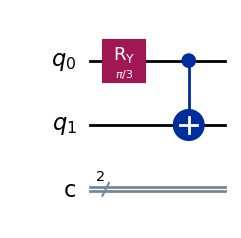

State Vector: [0.866+0.j 0.   +0.j 0.   +0.j 0.5  +0.j]
Probabilities: [0.75 0.   0.   0.25]
1024 Shot Results: {'11': 237, '00': 787}


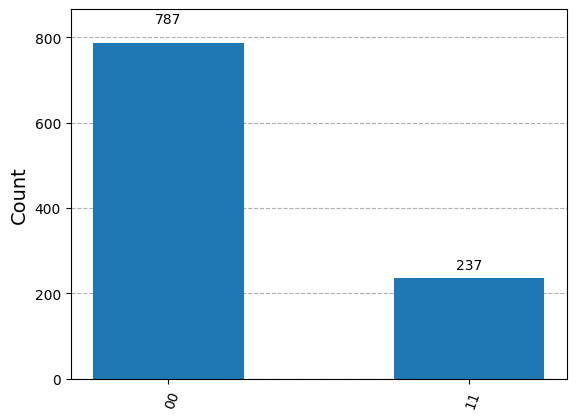

In [29]:
qc5 = QuantumCircuit(2, 2)

qc5.ry(np.pi/3, 0)
qc5.cx(0, 1)

state5 = Statevector.from_instruction(qc5)

display(qc5.draw("mpl"))

print("State Vector:", np.round(state5.data, 3))
print("Probabilities:", np.round(np.abs(state5.data)**2, 2))

qc5.measure([0, 1], [0, 1])
counts5 = simulator.run(qc5, shots=1024).result().get_counts()

print("1024 Shot Results:", counts5)

display(plot_histogram(counts5))

### Observation

The custom entangled state produced mainly 00 and 11 with unequal probabilities. The state vector and measurement results verified the expected entangled state.